In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.colors import LinearSegmentedColormap

In [2]:
def get_cartesian_style_axis(ax):
    # Hide top, right, left spines (borders)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Hide y-axis and y-ticks
    ax.yaxis.set_visible(True)

    # Only keep the bottom spine (x-axis)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    # Only show x-ticks
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    
# Define the functions f(x, y) and g(x, y) where x = alpha, y = omega
def f(x, y):
    return np.log(x**2 + y**2) / np.log(1 + y**2)  # 

def g(x, y, n):
    return (np.arctan2(y, x) + n * np.pi) / np.arctan2(y, 1)

# Define h(x, y, n) = f(x, y) - g(x, y)
def h(y, x, n):
    return f(x, y) - g(x, y, n)

# SYSTEM OF DDE

We have this system
$$
\begin{cases}
\dot{x_1} =& 1-x_2(t-\tau)x_1^\alpha\\
\dot{x_2} =& x_1 - x_2
\end{cases}
$$
The fixed point is $x_1^*=x_2^*=1.$
The boundary in the phase space ($\tau,\alpha$) at the Hopf bifurcation is given by the expression
\begin{equation}
   \tau=\frac{1}{\omega}\arccos(\omega^2-\alpha)=\frac{\sqrt{2}}{\sqrt{\sqrt{\alpha^4-2\alpha^2+5}-(\alpha^2+1)}}\cdot \arccos\biggl(\frac{\sqrt{\alpha^4-2\alpha+5}-(\alpha^2+1)}{2}-\alpha\biggr) 
\end{equation}


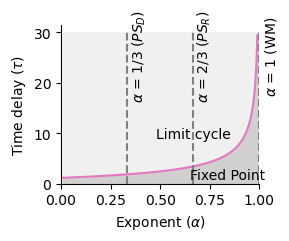

In [3]:
# Data
alpha = np.linspace(0.01, 0.99, 200)
z = (-alpha**2 - 1 + np.sqrt(alpha**4 - 2*alpha**2 + 5)) / 2
omega = np.sqrt(z)
tau = 1 / omega * np.arccos(z - alpha)

# Plot
plt.figure(figsize=(3, 2.4))
ymax = 30
# Fill above the curve
plt.fill_between(alpha, tau, ymax, color='#f0f0f0', alpha=1)

# Fill below the curve
plt.fill_between(alpha, 0, tau, color= "#d0d0d0", alpha=1)

# Curve
plt.plot(alpha, tau, color="tab:pink")

# Vertical lines and labels
plt.vlines(1/3, 0, ymax, linestyle="--", color="gray")
plt.vlines(2/3, 0, ymax, linestyle="--", color="gray")
plt.vlines(1, 0, ymax, linestyle="--", color="gray")
plt.text(0.35, 17, r"$\alpha$ = 1/3 ($PS_D$)", rotation = "vertical")
plt.text(0.68, 17, r"$\alpha$ = 2/3 ($PS_R$)", rotation = "vertical")
plt.text(1.02, 18, r"$\alpha$ = 1 (WM)", rotation = "vertical")
plt.text(0.48, 0.3*ymax, r"Limit cycle")
plt.text(0.65, 0.03*ymax, r"Fixed Point")

# Labels
plt.xlabel(r"Exponent ($\alpha$)")
plt.ylabel(r"Time delay $(\tau)$")

# Style
ax = plt.gca()
get_cartesian_style_axis(ax)

plt.ylim(bottom = 0)
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig("./neg_feedback_loop_paper_figures/tau_alpha.svg")

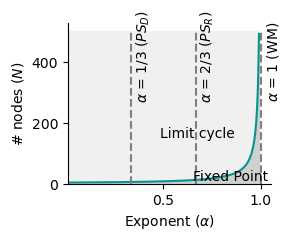

In [ ]:
# Initial guess for y
y0 = 0.6

# Create a range of x values
x_values = np.linspace(0.01, 0.99, 200) 
y_solutions = []

# Loop over multiple branches of the solution
for x in x_values:
    for n in range(-1, 50): 
        y_solution = fsolve(h, y0, args=(x, n))
      # Check if the solution is valid (e.g., within reasonable bounds)
        if y_solution<10 and y_solution>0: 
            y_solutions.append((x, y_solution[0], n))  # Store (x, y, n)
            found_solution=True
            break  
    if not found_solution:
        print("no solution for",x)
    y0=y_solution[0]
# Extract solutions for plotting
x_vals = [sol[0] for sol in y_solutions]
y_vals = [sol[1] for sol in y_solutions]
n_vals = [sol[2] for sol in y_solutions]


y_vals = np.array(y_vals)
x_vals = np.array(x_vals[0:len(y_vals)])
N=1-np.log(x_vals**2+y_vals**2)/np.log(1+y_vals**2)   

plt.figure(figsize=(3,2.4))
plt.plot(x_vals, N, color = "#06948E")
# Fill above the curve
ymax = 500
plt.fill_between(x_vals, N, ymax, color='#f0f0f0', alpha=1)

# Fill below the curve
plt.fill_between(x_vals, 0, N, color= "#d0d0d0", alpha=1)

#plt.plot(x_values, N2, label='y(x) solution')
plt.xlabel(r"Exponent ($\alpha)$")
plt.ylabel(r"# nodes $(N)$")
plt.vlines(1/3, 0, ymax, linestyle="--", color="gray")
plt.vlines(2/3, 0, ymax, linestyle="--", color="gray")
plt.vlines(1, 0, ymax, linestyle="--", color="gray")


ax = plt.gca()
get_cartesian_style_axis(ax)
plt.text(0.35, ymax-220, r"$\alpha$ = 1/3 ($PS_D$)", rotation = "vertical")
plt.text(0.68, ymax-220, r"$\alpha$ = 2/3 ($PS_R$)", rotation = "vertical")
plt.text(1.02, ymax-220, r"$\alpha$ = 1 (WM)", rotation = "vertical")
plt.text(0.48, 0.3*ymax, r"Limit cycle")
plt.text(0.65, 0.02*ymax, r"Fixed Point")
plt.ylim(bottom=0)
plt.xlim(left = 0.01)
plt.tight_layout()
plt.savefig("./neg_feedback_loop_paper_figures/n_alpha.svg")

# General parameters

In [5]:
def tau_alpha_curve_gen_par(a1,b1,a2,b2,alpha):
    x1star = (a1/b1*b2/a2)**(1/(1+alpha))
    x2star = (a2/b2)*x1star
    c = -b1*a2*x1star**alpha
    c2 = (alpha*c/b2)**2+b2**2
    z = (-c2+np.sqrt(c2**2-4*c**2*(alpha**2-1)))/2
    omega = np.sqrt(z)
    tau = 1/omega * np.arccos((z/c-alpha))
    return alpha, tau

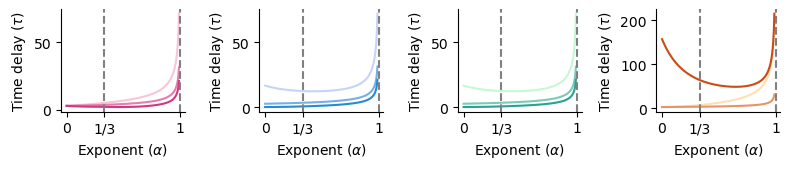

In [6]:

alpha = np.linspace(0, 0.99, 200)

# Vary each parameter over a set of values
param_sets = {
    "a1": [0.1, 1, 100],
    "b1": [0.1, 1, 100],
    "a2": [0.1, 1, 100],
    "b2": [0.1, 1, 100],
}

default_params = {
    "a1": 1,
    "b1": 1,
    "a2": 1,
    "b2": 1,
}
colormaps = {
    "a1": LinearSegmentedColormap.from_list("pink_shades", ["#f8c6d4", "#d33682"]),
    "b1": LinearSegmentedColormap.from_list("blue_shades", ["#c6d4f8", "#268bd2"]),
    "a2": LinearSegmentedColormap.from_list("green_shades", ["#c6f8d4", "#2aa198"]),
    "b2": LinearSegmentedColormap.from_list("orange_shades", ["#ffe0b3", "#cb4b16"]),
}
alpha = np.linspace(0, 0.99, 200)
fig, axs = plt.subplots(1, 4, figsize=(8, 1.8))
axs = axs.flatten()

for ax, (param_name, param_values) in zip(axs, param_sets.items()):
    cmap = colormaps[param_name]
    colors = [cmap(i) for i in np.linspace(0.0, 1.0, len(param_values))]
    for color, val in zip(colors, param_values):
        # Copy default parameters and override one
        params = default_params.copy()
        params[param_name] = val
        a1, b1, a2, b2 = params["a1"], params["b1"], params["a2"], params["b2"]

        alpha_plot, tau = tau_alpha_curve_gen_par(a1, b1, a2, b2, alpha)
        ax.plot(alpha_plot, tau, label=f"{param_name} = {val:.2f}", color=color)

    #ax.set_title(f"Varying {param_name}")
    ax.set_xlabel(r"Exponent ($\alpha$)")
    ax.set_ylabel(r"Time delay $(\tau)$")
    get_cartesian_style_axis(ax)
    ax.axvline(1/3, linestyle="--", color="gray")
    ax.axvline(1, linestyle="--", color="gray")
    ax.set_xticks([0,1/3,1])
    ax.set_xticklabels(["0", "1/3", "1"])
    #ax.legend()

plt.tight_layout()
plt.savefig("general_params.svg")
plt.show()